# Lorenz63 square obs: PF/Benchmark/Training visualization

This notebook focuses on `dataset=lorenz63`, with configurable `obs_fn` (currently `square`).
All IO is under `save/`.

In [81]:
# Path bootstrap: if running from ./test_notebooks, move to project root
from pathlib import Path
import os

cwd = Path.cwd().resolve()
if cwd.name == 'test_notebooks':
    os.chdir(cwd.parent)
    cwd = Path.cwd().resolve()

print('Current working directory:', cwd)


Current working directory: /home/bhchen/LearnKalmanGain


In [82]:
import os
import re
import glob
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# torch is required to read output_records_*.pt
import torch


In [83]:
# Ensure cwd is project root (where ./save exists)
cwd = Path.cwd().resolve()
if not (cwd / 'save').exists() and (cwd.parent / 'save').exists():
    os.chdir(cwd.parent)

PROJECT_ROOT = Path.cwd().resolve()
SAVE_DIR = PROJECT_ROOT / 'save'
print('PROJECT_ROOT =', PROJECT_ROOT)
print('SAVE_DIR exists =', SAVE_DIR.exists())


PROJECT_ROOT = /home/bhchen/LearnKalmanGain
SAVE_DIR exists = True


In [84]:
# =========================
# User config
# =========================
DATASET = 'lorenz63'
OBS_FN = 'square'  # currently implemented and tested
if OBS_FN != 'square':
    raise NotImplementedError('This notebook currently implements OBS_FN="square" only.')

SIGMA_Y = 16.97
SEED = 42
PF_N = 1000000
TEST_LEN = 500

STEP_LIST = [200, 300, 400]

# Display control: currently do not show PCA12
SHOW_PCA12 = False
BASE_VIEWS = ['12', '13', '23']
VIEWS = BASE_VIEWS + (['PCA12'] if SHOW_PCA12 else [])
VIEW_ALIASES = {
    '12': ['12', 'xy'],
    '13': ['13', 'xz'],
    '23': ['23', 'yz'],
    'PCA12': ['PCA12'],
}

# Image crop ratios (for every displayed panel)
# Left/bottom crop 10%, right/top crop 5%
CROP_LEFT_PCT = 0.10
CROP_BOTTOM_PCT = 0.10
CROP_RIGHT_PCT = 0.05
CROP_TOP_PCT = 0.05


# Grid text/size controls
GRID_COL_TITLE_FONTSIZE = 15
GRID_ROW_LABEL_FONTSIZE = 20
GRID_COL_TITLE_WRAP = 20
GRID_COL_WIDTH = 3.7
GRID_ROW_HEIGHT = 3.4

N_LIST = [100]  # each method occupies one row per N
VAL_N_LIST = [5, 10, 15, 20, 40, 60, 100]

USE_POST = True
USE_ADAPTIVE = True
KIND = 'post' if USE_POST else 'prior'
RANGE_MODE = 'adaptive' if USE_ADAPTIVE else 'fixed'

PF_VIS_DIR = SAVE_DIR / f'{DATASET}_pf_vis_{OBS_FN}'
BENCHMARK_GLOB = str(SAVE_DIR / f'benchmark_{DATASET}_{SIGMA_Y}_*')

# Preferred source requested by user. If empty/no subdirs with records, fallback is used.
TRAINING_ROOT_PRIMARY = SAVE_DIR / f'pf_analysis_{DATASET}_{OBS_FN}'
TRAINING_ROOT_FALLBACK = SAVE_DIR / f'{DATASET}_obs_fn_{OBS_FN}'

FIG_SAVE_DIR = SAVE_DIR / 'figures' / f'{DATASET}_{OBS_FN}_notebook'
FIG_SAVE_DIR.mkdir(parents=True, exist_ok=True)
print('FIG_SAVE_DIR =', FIG_SAVE_DIR)


FIG_SAVE_DIR = /home/bhchen/LearnKalmanGain/save/figures/lorenz63_square_notebook


In [85]:
def safe_torch_load(path):
    path = str(path)
    try:
        return torch.load(path, map_location='cpu', weights_only=False)
    except TypeError:
        return torch.load(path, map_location='cpu')


def crop_image(
    img,
    left_pct=0.10,
    right_pct=0.05,
    top_pct=0.05,
    bottom_pct=0.10,
):
    # Crop image by percentages from each side.
    if img is None or getattr(img, 'ndim', 0) < 2:
        return img

    h, w = img.shape[:2]
    x0 = int(round(w * float(left_pct)))
    x1 = w - int(round(w * float(right_pct)))
    y0 = int(round(h * float(top_pct)))
    y1 = h - int(round(h * float(bottom_pct)))

    x0 = max(0, min(x0, w - 1))
    x1 = max(x0 + 1, min(x1, w))
    y0 = max(0, min(y0, h - 1))
    y1 = max(y0 + 1, min(y1, h))

    return img[y0:y1, x0:x1, ...]


def _score_path(path, preferred_tokens=None):
    preferred_tokens = preferred_tokens or []
    s = 0
    p = str(path)
    for tok in preferred_tokens:
        if tok in p:
            s += 10
    return s


def pick_best_path(paths, preferred_tokens=None):
    paths = list(paths)
    if not paths:
        return None
    scored = sorted(paths, key=lambda p: _score_path(p, preferred_tokens), reverse=True)
    return Path(scored[0])


def discover_benchmark_dirs():
    dirs = [Path(p) for p in glob.glob(BENCHMARK_GLOB) if Path(p).is_dir()]
    dirs = sorted(dirs)
    out = []
    prefix = f'benchmark_{DATASET}_{SIGMA_Y}_'
    for d in dirs:
        name = d.name
        method = name.replace(prefix, '') if name.startswith(prefix) else name
        out.append({'label': f'Classic-{method}', 'dir': d, 'kind': 'classic'})
    return out


def _has_any_output_records(folder):
    return any(folder.glob('output_records_*.pt'))


def discover_training_dirs(root: Path):
    if (not root.exists()) or (not root.is_dir()):
        return []
    cands = [d for d in sorted(root.iterdir()) if d.is_dir() and _has_any_output_records(d)]
    return cands


def pretty_training_label(folder_name: str):
    # Example: ..._es_joint_EtE-LResNone_square
    m = re.search(r'_(es|nl2|nes|l2|nll|pre_nll|wpf_ed|wpf_ammd|es_wpf_ed|es_wpf_ammd)_joint_([^_/]+)', folder_name)
    if m:
        model = m.group(1).upper()
        loss_name = m.group(2)
        loss_name = loss_name.replace('None', '').strip('_')
        return f'Train-{model}-{loss_name}'
    return f'Train-{folder_name[-30:]}'


def build_training_specs():
    primary = discover_training_dirs(TRAINING_ROOT_PRIMARY)
    using_root = TRAINING_ROOT_PRIMARY
    if len(primary) == 0:
        primary = discover_training_dirs(TRAINING_ROOT_FALLBACK)
        using_root = TRAINING_ROOT_FALLBACK

    specs = []
    for d in primary:
        specs.append({'label': pretty_training_label(d.name), 'dir': d, 'kind': 'train'})
    return specs, using_root


def find_pf_image(step: int, view: str):
    aliases = VIEW_ALIASES[view]
    candidates = []
    for v in aliases:
        candidates.extend(glob.glob(str(PF_VIS_DIR / f'*timestep{step}_*_{KIND}_{RANGE_MODE}_{v}.png')))
        # fallback to opposite range mode if selected one does not exist
        other_mode = 'fixed' if RANGE_MODE == 'adaptive' else 'adaptive'
        candidates.extend(glob.glob(str(PF_VIS_DIR / f'*timestep{step}_*_{KIND}_{other_mode}_{v}.png')))

    preferred = [f'len{TEST_LEN}', f'pfN{PF_N}', f'_{SEED}_', f'_{KIND}_{RANGE_MODE}_']
    return pick_best_path(candidates, preferred_tokens=preferred)


def find_method_image(method_dir: Path, N: int, step: int, view: str):
    aliases = VIEW_ALIASES[view]
    patterns = []
    for v in aliases:
        # benchmark style
        patterns.append(f'test_{N}_0_classic_g0_step{step}_0_{KIND}_{RANGE_MODE}_{v}.png')
        # training style
        patterns.append(f'test_{N}_0_g0_step{step}_0_{KIND}_{RANGE_MODE}_{v}.png')
        # looser fallback
        patterns.append(f'test_{N}_0*step{step}_0_{KIND}_{RANGE_MODE}_{v}.png')

    candidates = []
    for pat in patterns:
        candidates.extend(glob.glob(str(method_dir / pat)))

    preferred = [f'test_{N}_0', f'step{step}_0', f'_{KIND}_{RANGE_MODE}_']
    return pick_best_path(candidates, preferred_tokens=preferred)


def metric_from_record(record_dict, key_candidates):
    for base in [record_dict.get('nn', {}), record_dict]:
        for k in key_candidates:
            if k in base and base[k] is not None:
                try:
                    return float(base[k])
                except Exception:
                    continue
    return np.nan


In [86]:
benchmark_specs = discover_benchmark_dirs()
training_specs, training_root_used = build_training_specs()

print('PF_VIS_DIR:', PF_VIS_DIR)
print('Benchmark dirs found:', len(benchmark_specs))
for s in benchmark_specs:
    print('  -', s['label'], '|', s['dir'])

print('Training root used:', training_root_used)
print('Training dirs found:', len(training_specs))
for s in training_specs:
    print('  -', s['label'], '|', s['dir'])


PF_VIS_DIR: /home/bhchen/LearnKalmanGain/save/lorenz63_pf_vis_square
Benchmark dirs found: 2
  - Classic-ESRF | /home/bhchen/LearnKalmanGain/save/benchmark_lorenz63_16.97_ESRF
  - Classic-EnKF | /home/bhchen/LearnKalmanGain/save/benchmark_lorenz63_16.97_EnKF
Training root used: /home/bhchen/LearnKalmanGain/save/lorenz63_obs_fn_square
Training dirs found: 4
  - Train-ES-EtE-LRes | /home/bhchen/LearnKalmanGain/save/lorenz63_obs_fn_square/2026-02-22_20-23lorenz63_16.97_10_60_8192_es_joint_EtE-LResNone_square
  - Train-NL2-EtE-LRes | /home/bhchen/LearnKalmanGain/save/lorenz63_obs_fn_square/2026-02-22_20-23lorenz63_16.97_10_60_8192_nl2_joint_EtE-LResNone_square
  - Train-ES-CorrTerms | /home/bhchen/LearnKalmanGain/save/lorenz63_obs_fn_square/2026-02-22_20-24lorenz63_16.97_10_60_8192_es_joint_CorrTermsNone_square
  - Train-NL2-CorrTerms | /home/bhchen/LearnKalmanGain/save/lorenz63_obs_fn_square/2026-02-22_20-24lorenz63_16.97_10_60_8192_nl2_joint_CorrTermsNone_square


Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_square_notebook/grid_step200_post_adaptive_transposed.png


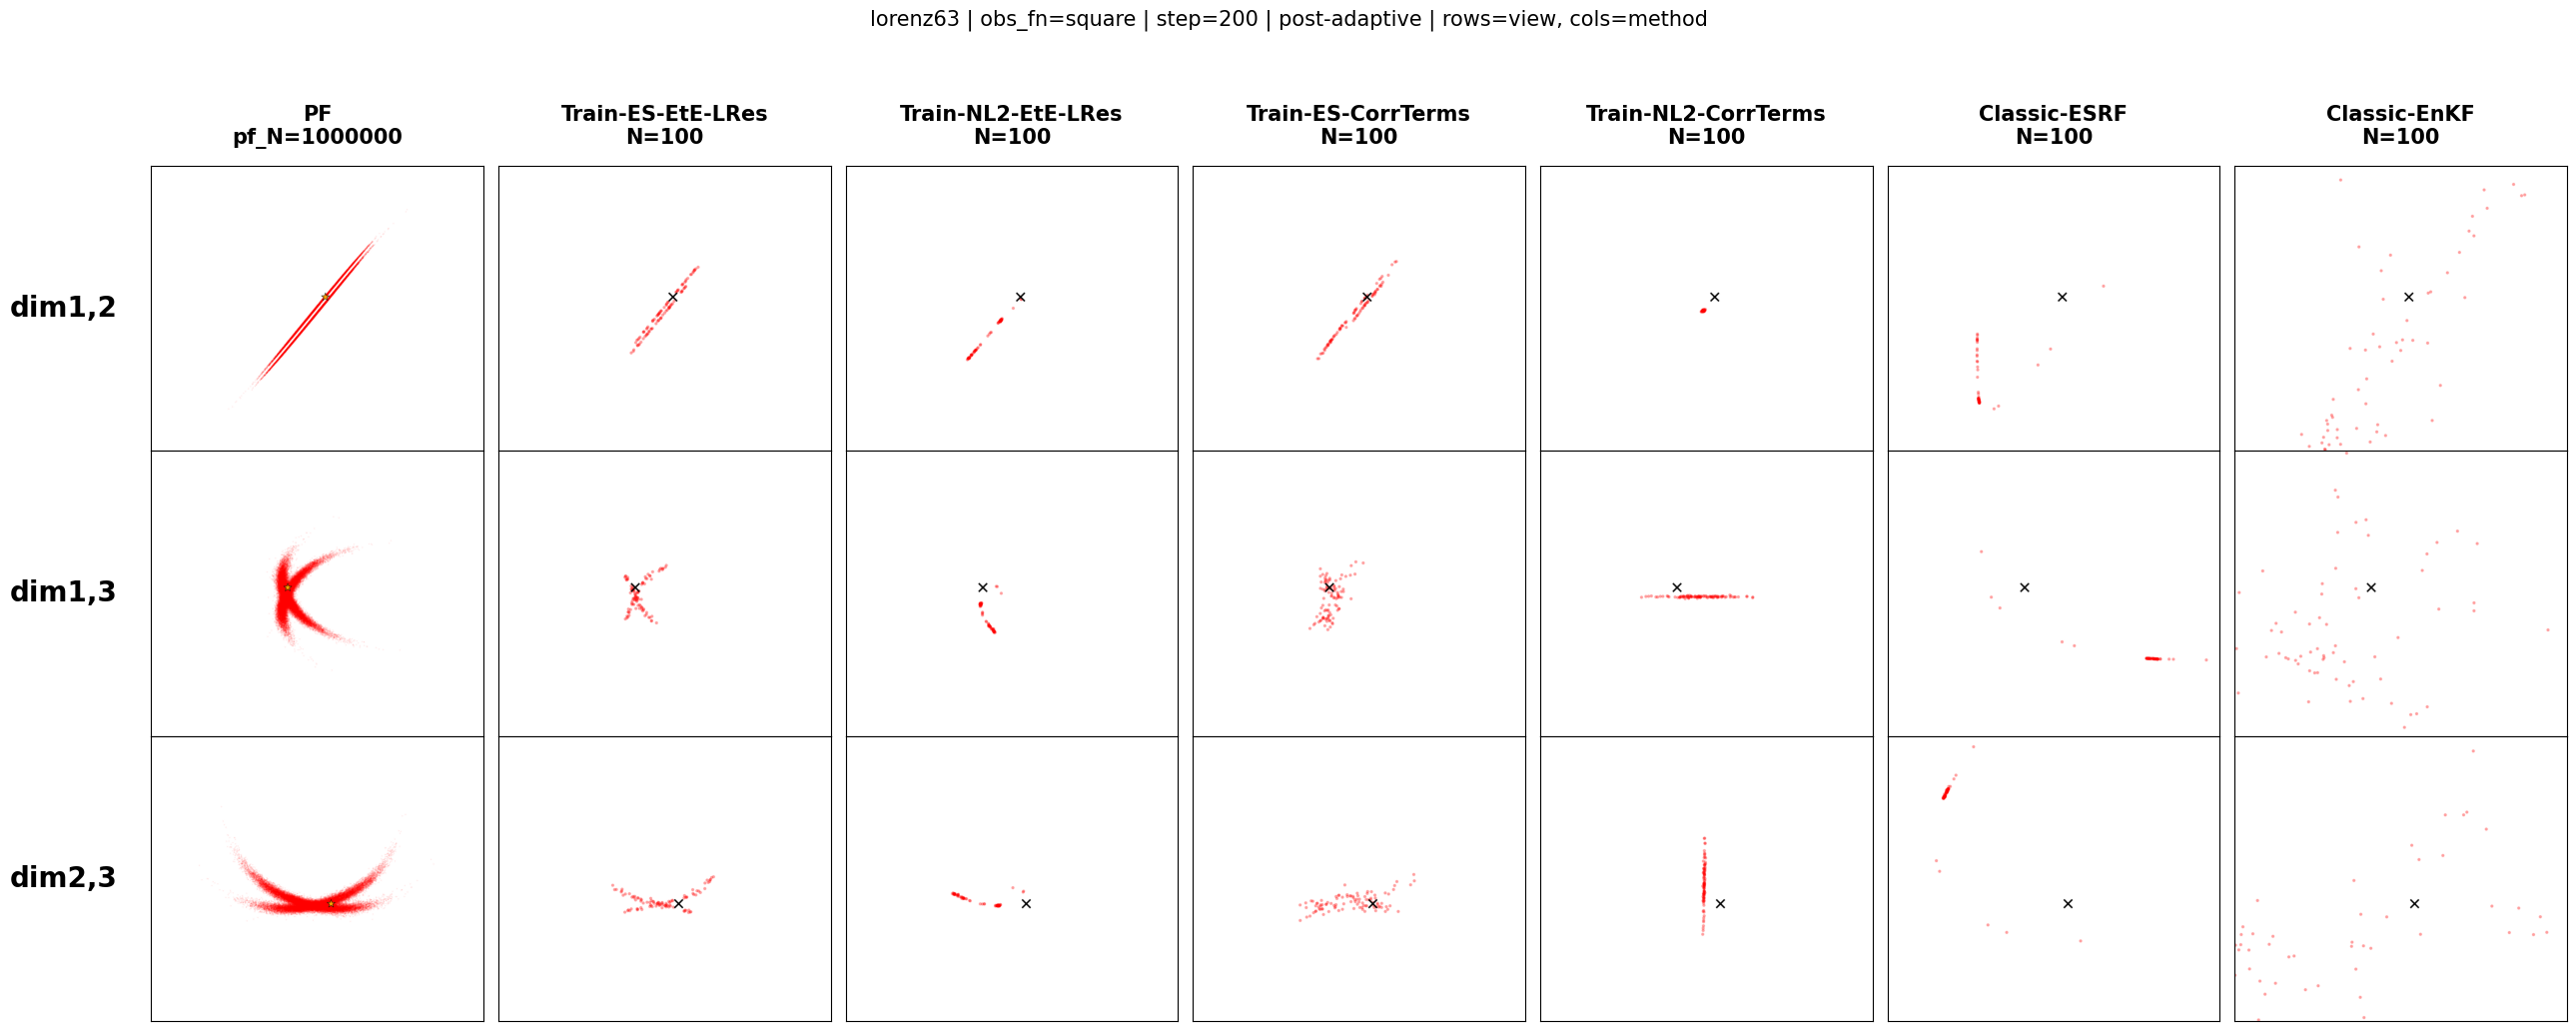

Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_square_notebook/grid_step300_post_adaptive_transposed.png


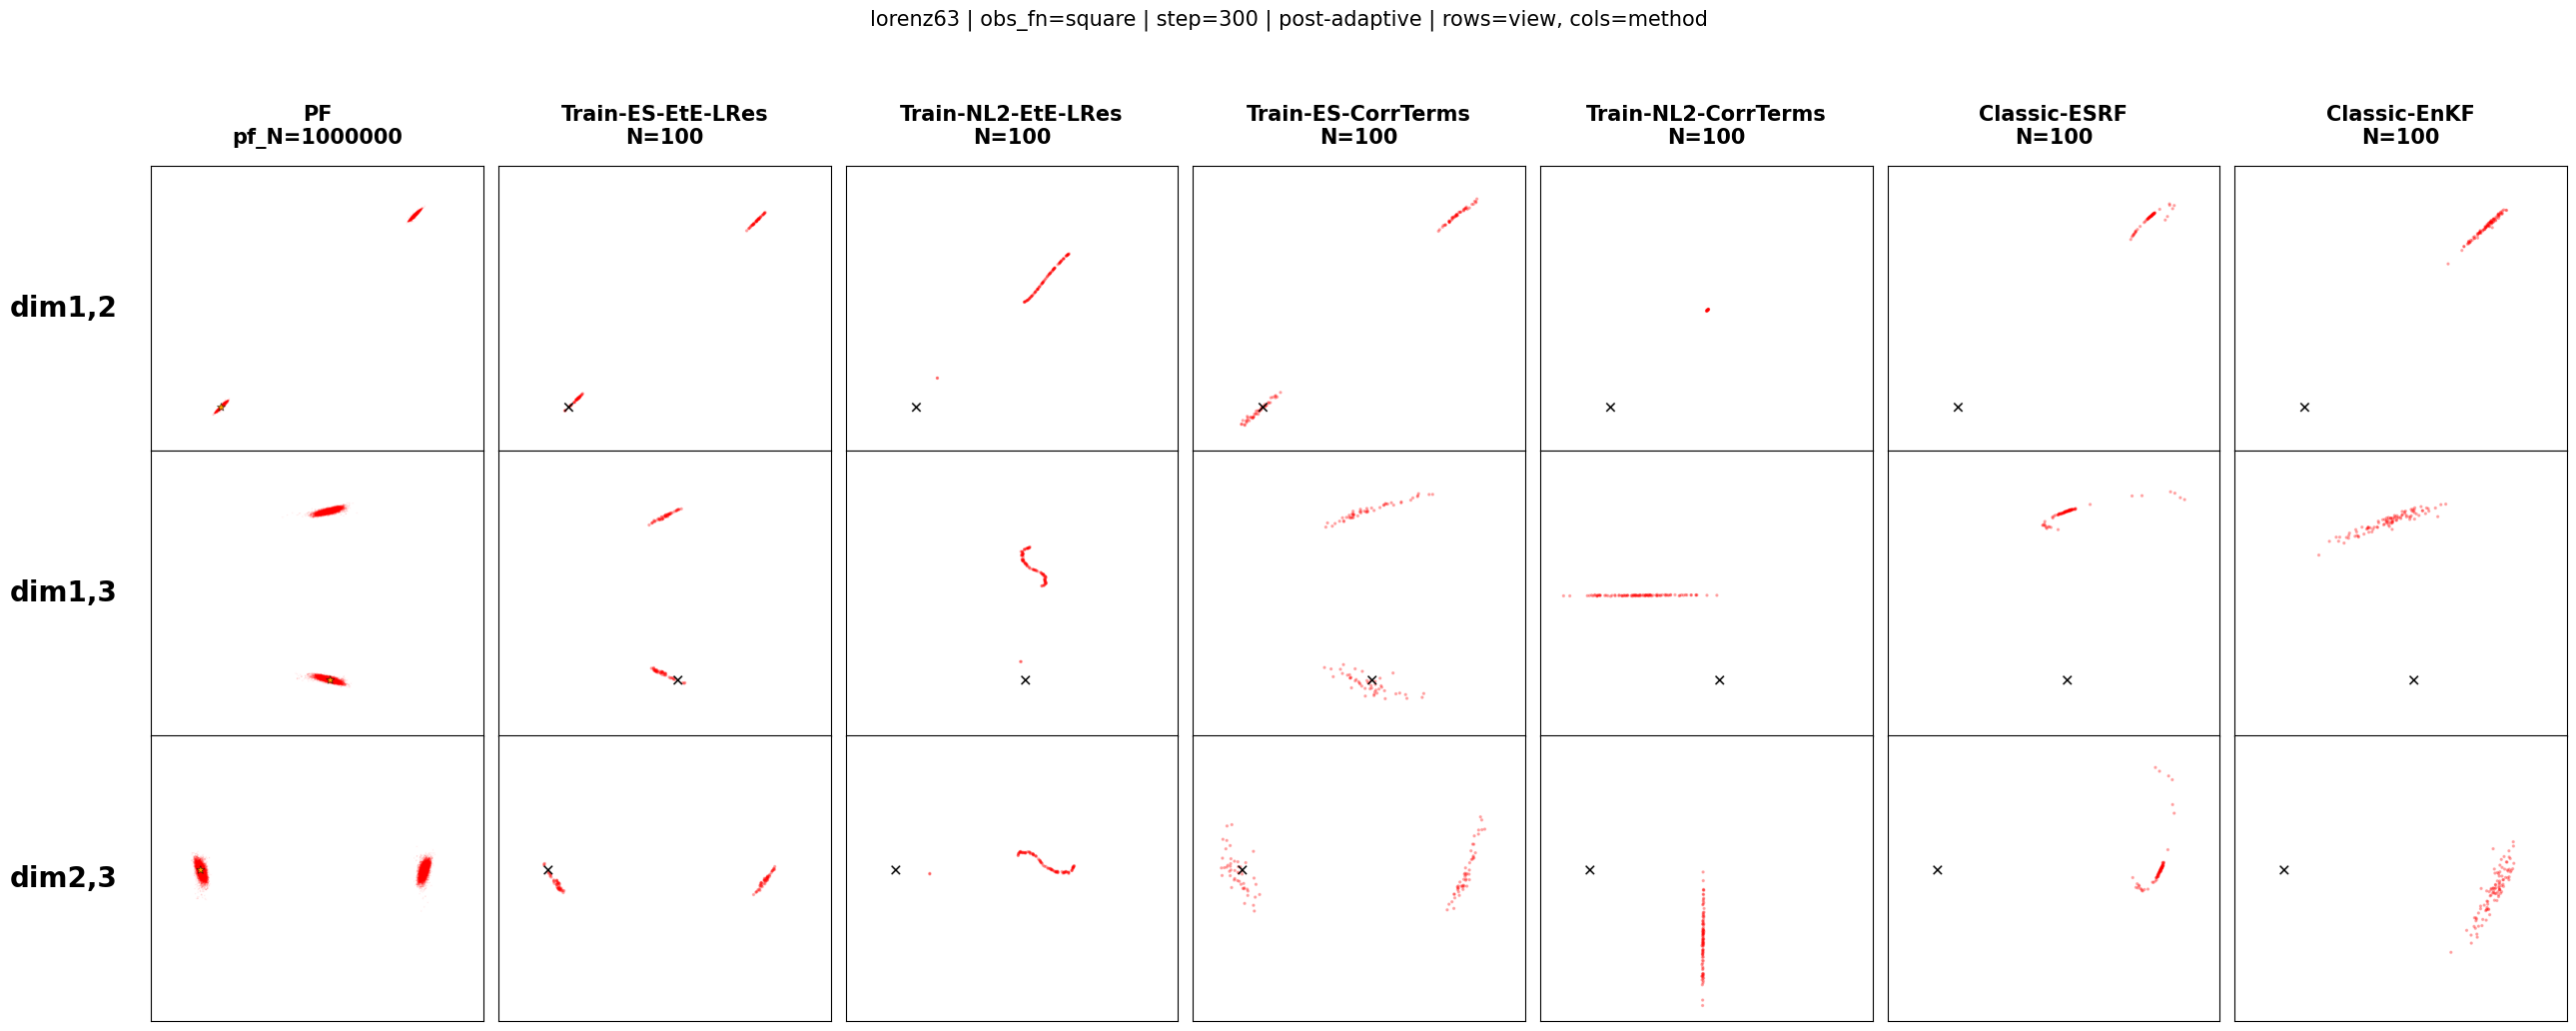

Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_square_notebook/grid_step400_post_adaptive_transposed.png


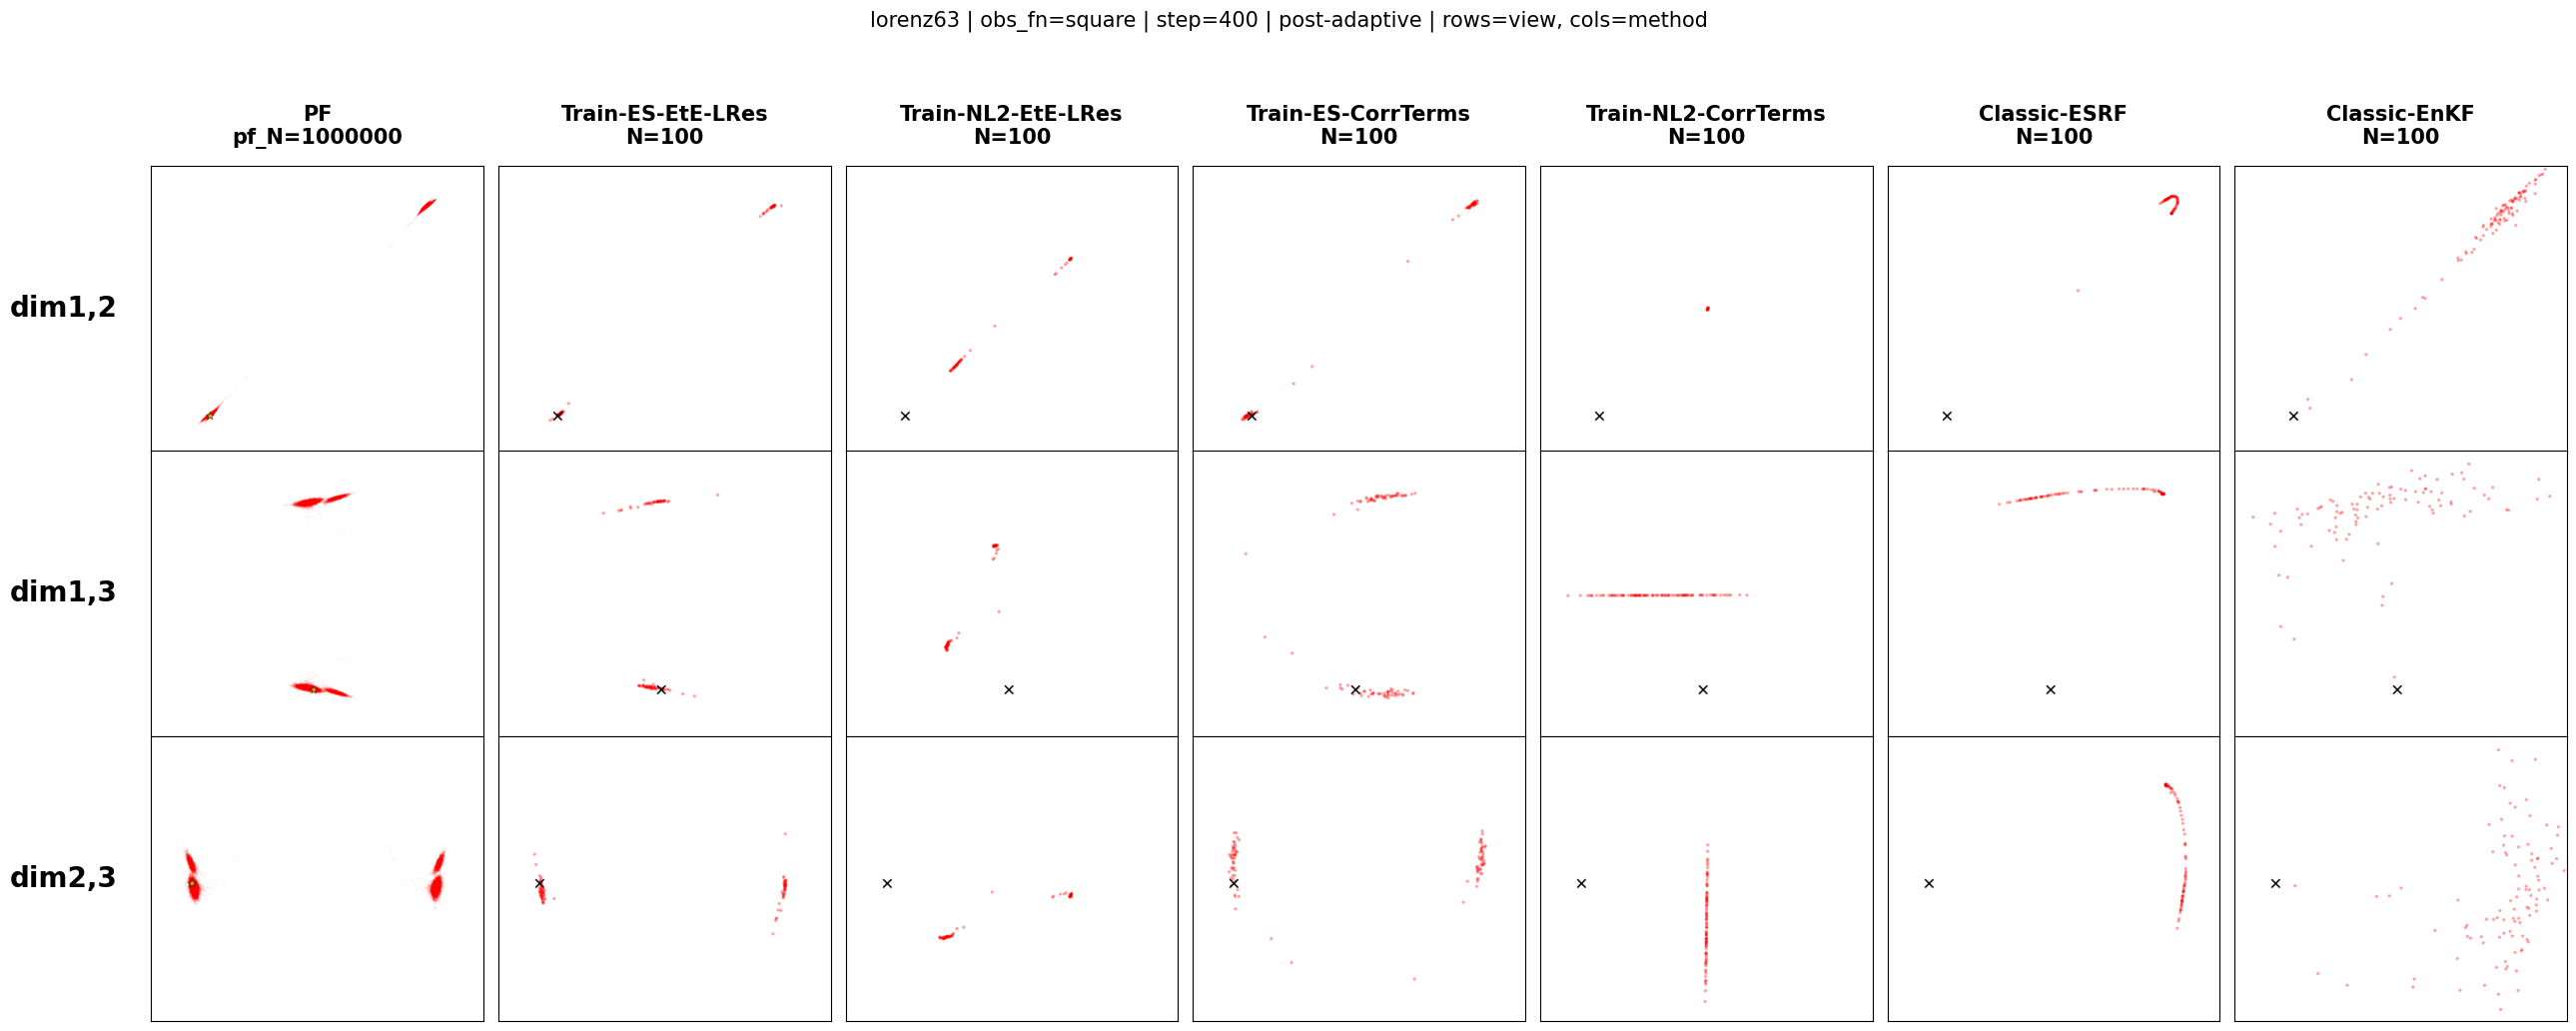

In [87]:
def build_columns_for_grid():
    cols = [{'type': 'pf', 'method_label': 'PF', 'dir': PF_VIS_DIR, 'N': None}]

    # Training methods first
    for spec in training_specs:
        for N in N_LIST:
            cols.append({
                'type': 'method',
                'method_label': spec['label'],
                'dir': spec['dir'],
                'N': N,
                'group': 'train',
            })

    # Classic methods last
    for spec in benchmark_specs:
        for N in N_LIST:
            cols.append({
                'type': 'method',
                'method_label': spec['label'],
                'dir': spec['dir'],
                'N': N,
                'group': 'classic',
            })

    return cols


def view_to_dim_label(view: str) -> str:
    mapping = {
        '12': 'dim1,2',
        '13': 'dim1,3',
        '23': 'dim2,3',
        'PCA12': 'PCA1,2',
        'xy': 'dim1,2',
        'xz': 'dim1,3',
        'yz': 'dim2,3',
    }
    return mapping.get(view, str(view))


def format_method_header(col):
    from textwrap import fill

    method_line = fill(str(col.get('method_label', '')), width=int(GRID_COL_TITLE_WRAP))
    if col['type'] == 'pf':
        n_line = f'pf_N={PF_N}'
    else:
        n_line = f"N={col['N']}"
    return f"{method_line}\n{n_line}"


def plot_grid_for_step(step: int, save=True):
    cols = build_columns_for_grid()
    n_rows = len(VIEWS)      # row = view
    n_cols = len(cols)       # col = method

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(GRID_COL_WIDTH * n_cols, GRID_ROW_HEIGHT * n_rows),
        squeeze=False,
    )

    # Column headers: method on first line, N on second line
    for c, col in enumerate(cols):
        axes[0, c].set_title(
            format_method_header(col),
            fontsize=GRID_COL_TITLE_FONTSIZE,
            fontweight='bold',
            linespacing=1.2,
            pad=16,
        )

    for r, view in enumerate(VIEWS):
        for c, col in enumerate(cols):
            ax = axes[r, c]
            if col['type'] == 'pf':
                img_path = find_pf_image(step=step, view=view)
            else:
                img_path = find_method_image(method_dir=col['dir'], N=col['N'], step=step, view=view)

            if img_path is not None and Path(img_path).exists():
                try:
                    img = plt.imread(str(img_path))
                    img = crop_image(
                        img,
                        left_pct=CROP_LEFT_PCT,
                        right_pct=CROP_RIGHT_PCT,
                        top_pct=CROP_TOP_PCT,
                        bottom_pct=CROP_BOTTOM_PCT,
                    )
                    ax.imshow(img)
                except Exception:
                    ax.text(0.5, 0.5, 'Read error', ha='center', va='center', fontsize=12)
                    ax.set_facecolor('#eeeeee')
            else:
                ax.text(0.5, 0.5, 'Missing', ha='center', va='center', fontsize=12)
                ax.set_facecolor('#f7f7f7')

            ax.set_xticks([])
            ax.set_yticks([])

            # Row labels with large font and dim-style naming
            if c == 0:
                ax.set_ylabel(
                    view_to_dim_label(view),
                    rotation=0,
                    ha='right',
                    va='center',
                    labelpad=24,
                    fontsize=GRID_ROW_LABEL_FONTSIZE,
                    fontweight='bold',
                )

    plt.suptitle(
        f'{DATASET} | obs_fn={OBS_FN} | step={step} | {KIND}-{RANGE_MODE} | rows=view, cols=method',
        fontsize=15,
        y=1.01,
    )
    plt.tight_layout(rect=[0.0, 0.0, 1.0, 0.96])

    if save:
        out = FIG_SAVE_DIR / f'grid_step{step}_{KIND}_{RANGE_MODE}_transposed.png'
        plt.savefig(out, dpi=180, bbox_inches='tight')
        print('Saved:', out)

    plt.show()


for step in STEP_LIST:
    plot_grid_for_step(step)


Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_square_notebook/prior_2d_step200_N100_adaptive.png


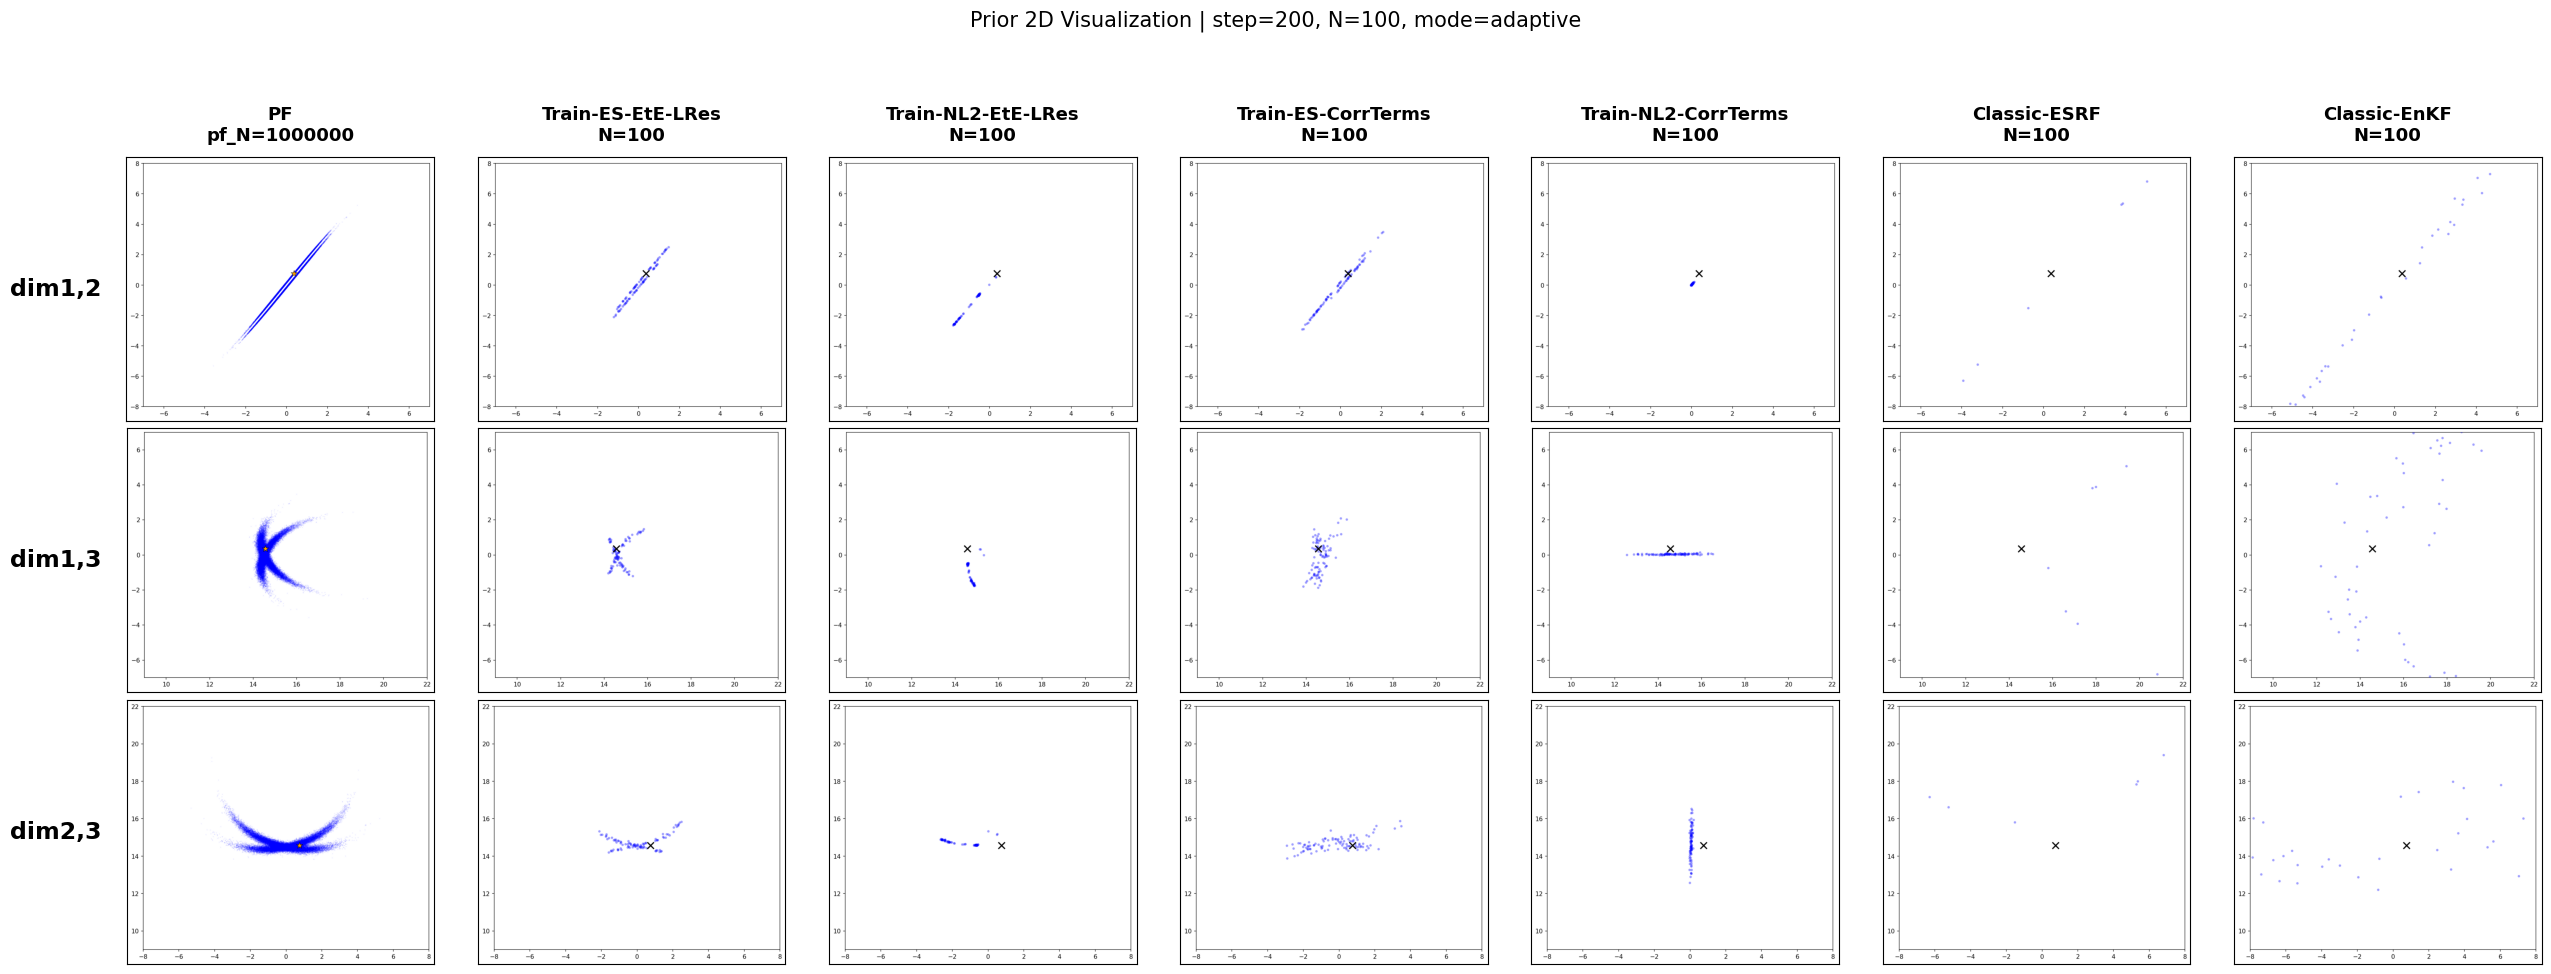

Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_square_notebook/prior_density1d_step200_N100.png


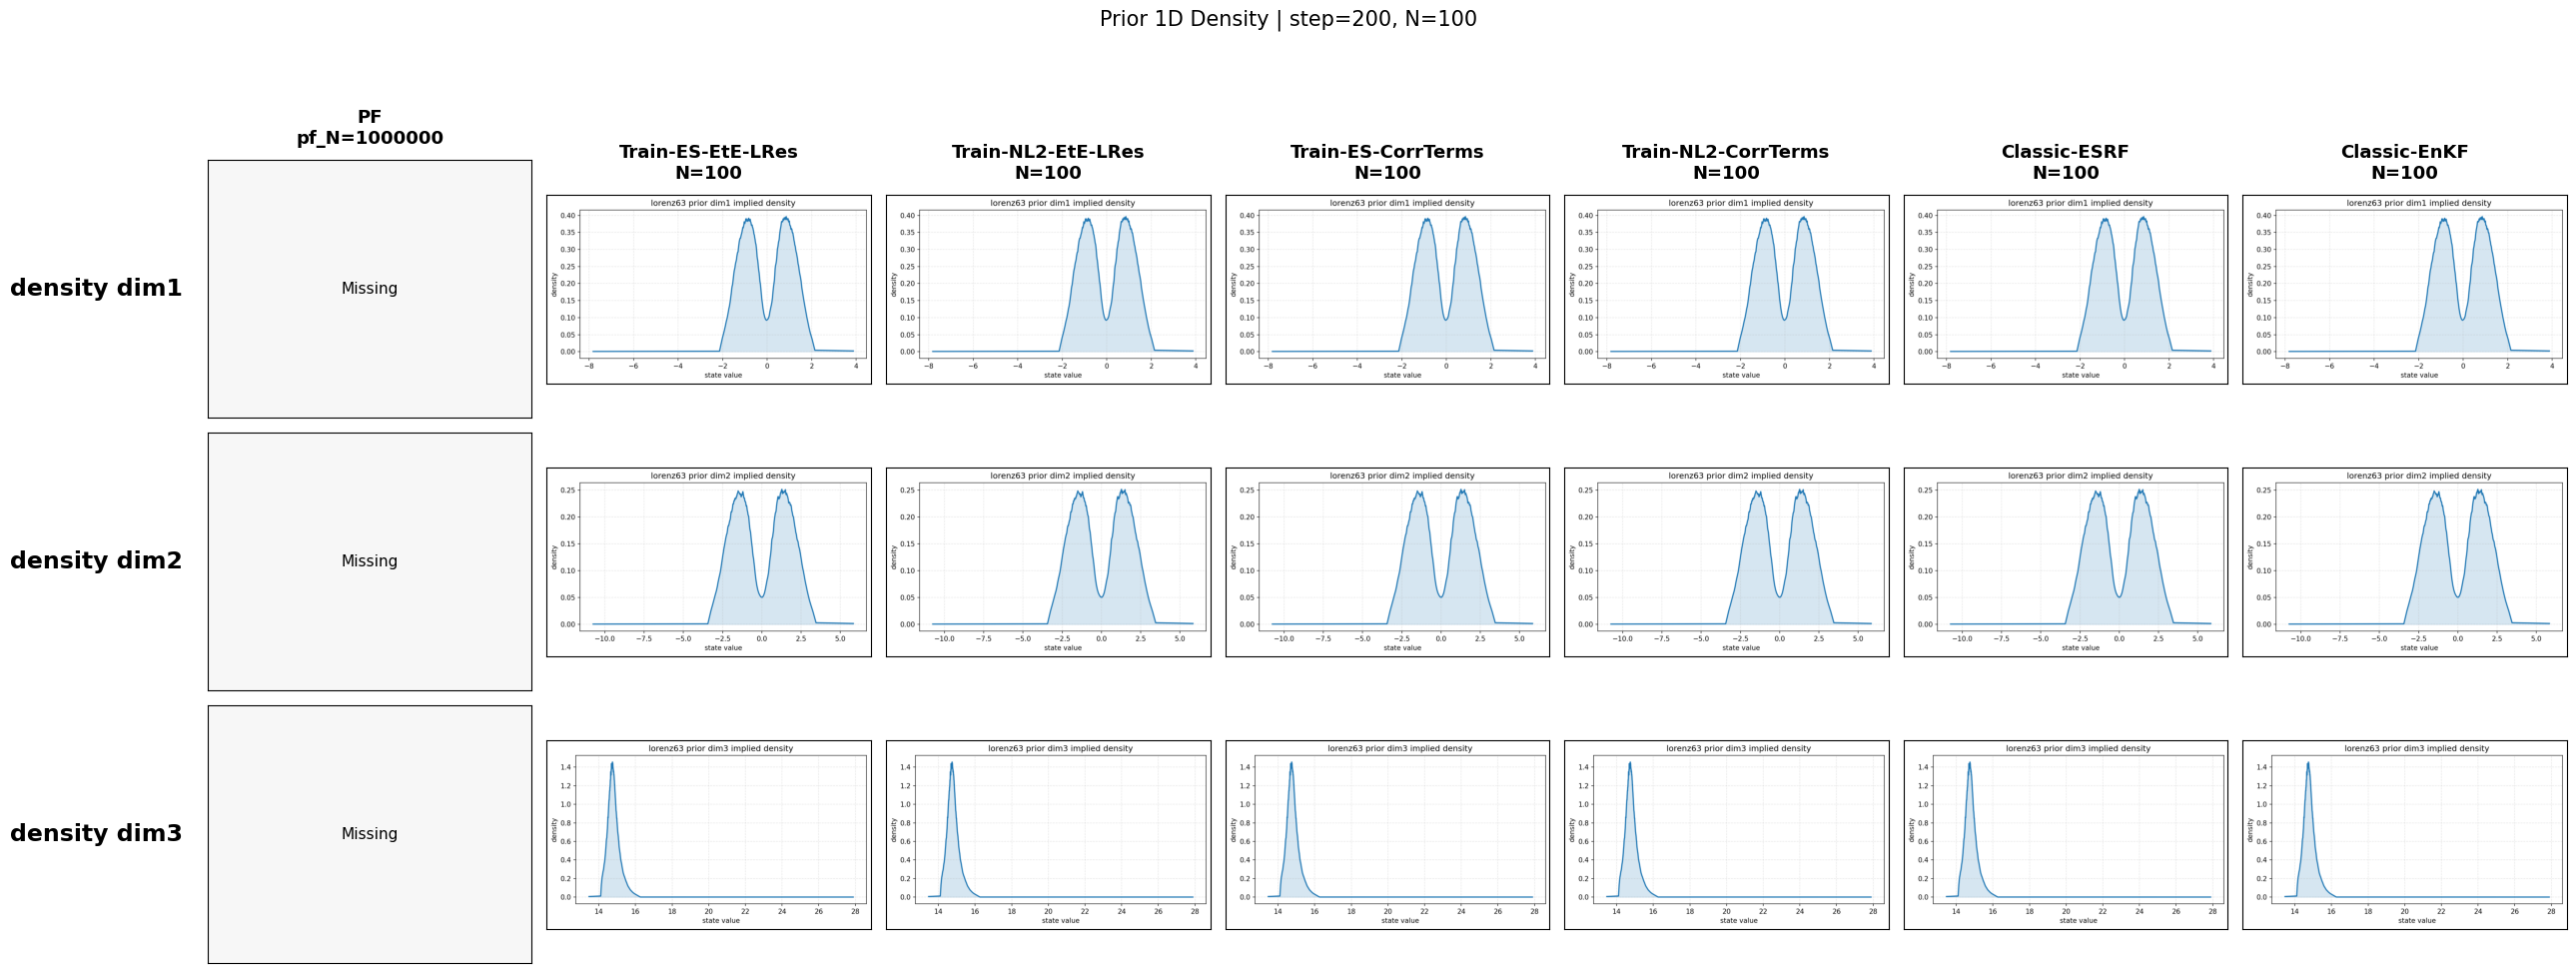

In [88]:
# =========================
# Extra block config
# =========================
EXTRA_STEP = STEP_LIST[0] if len(STEP_LIST) > 0 else 200
EXTRA_N = N_LIST[0] if len(N_LIST) > 0 else 100
EXTRA_KIND = 'prior'
EXTRA_RANGE_MODE = 'adaptive'

# Keep density axes/text more complete by default
APPLY_CROP_ON_EXTRA = False

EXTRA_COL_TITLE_FONTSIZE = 13
EXTRA_ROW_LABEL_FONTSIZE = 17
EXTRA_COL_WIDTH = 3.7
EXTRA_ROW_HEIGHT = 3.2


def build_columns_for_specific_N(n_value: int):
    cols = [{'type': 'pf', 'method_label': 'PF', 'dir': PF_VIS_DIR, 'N': None}]
    # training first
    for spec in training_specs:
        cols.append({
            'type': 'method',
            'method_label': spec['label'],
            'dir': spec['dir'],
            'N': n_value,
            'group': 'train',
        })
    # classic last
    for spec in benchmark_specs:
        cols.append({
            'type': 'method',
            'method_label': spec['label'],
            'dir': spec['dir'],
            'N': n_value,
            'group': 'classic',
        })
    return cols


def _find_pf_image_with_kind(step: int, token: str, kind='prior', range_mode='adaptive'):
    candidates = []
    candidates.extend(glob.glob(str(PF_VIS_DIR / f'*timestep{step}_*_{kind}_{range_mode}_{token}.png')))
    other_mode = 'fixed' if range_mode == 'adaptive' else 'adaptive'
    candidates.extend(glob.glob(str(PF_VIS_DIR / f'*timestep{step}_*_{kind}_{other_mode}_{token}.png')))
    preferred = [f'len{TEST_LEN}', f'pfN{PF_N}', f'_{SEED}_', f'_{kind}_{range_mode}_']
    return pick_best_path(candidates, preferred_tokens=preferred)


def _find_method_image_by_suffix(method_dir: Path, N: int, suffix: str):
    patterns = [
        f'test_{N}_0_classic_g0_{suffix}',
        f'test_{N}_0_g0_{suffix}',
        f'test_{N}_0*_{suffix}',
    ]
    candidates = []
    for pat in patterns:
        candidates.extend(glob.glob(str(method_dir / pat)))
    preferred = [f'test_{N}_0']
    return pick_best_path(candidates, preferred_tokens=preferred)


def _load_img_for_panel(path):
    if path is None or (not Path(path).exists()):
        return None
    img = plt.imread(str(path))
    if APPLY_CROP_ON_EXTRA:
        img = crop_image(
            img,
            left_pct=CROP_LEFT_PCT,
            right_pct=CROP_RIGHT_PCT,
            top_pct=CROP_TOP_PCT,
            bottom_pct=CROP_BOTTOM_PCT,
        )
    return img


def _plot_panel_grid(row_specs, find_image_fn, title: str, out_name: str):
    cols = build_columns_for_specific_N(EXTRA_N)
    n_rows = len(row_specs)
    n_cols = len(cols)

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(EXTRA_COL_WIDTH * n_cols, EXTRA_ROW_HEIGHT * n_rows),
        squeeze=False,
    )

    for c, col in enumerate(cols):
        axes[0, c].set_title(format_method_header(col), fontsize=EXTRA_COL_TITLE_FONTSIZE, fontweight='bold', pad=12)

    for r, row in enumerate(row_specs):
        row_label = row['label']
        row_key = row['key']
        for c, col in enumerate(cols):
            ax = axes[r, c]
            img_path = find_image_fn(col=col, row_key=row_key)
            img = _load_img_for_panel(img_path)
            if img is None:
                ax.text(0.5, 0.5, 'Missing', ha='center', va='center', fontsize=11)
                ax.set_facecolor('#f7f7f7')
            else:
                ax.imshow(img)

            ax.set_xticks([])
            ax.set_yticks([])

            if c == 0:
                ax.set_ylabel(
                    row_label,
                    rotation=0,
                    ha='right',
                    va='center',
                    labelpad=18,
                    fontsize=EXTRA_ROW_LABEL_FONTSIZE,
                    fontweight='bold',
                )

    plt.suptitle(title, fontsize=15, y=1.01)
    plt.tight_layout(rect=[0.0, 0.0, 1.0, 0.96])

    out = FIG_SAVE_DIR / out_name
    plt.savefig(out, dpi=180, bbox_inches='tight')
    print('Saved:', out)
    plt.show()


# -------------------------
# Block A: prior 2D visualization (adaptive 12/13/23)
# -------------------------
prior_2d_rows = [
    {'label': 'dim1,2', 'key': '12'},
    {'label': 'dim1,3', 'key': '13'},
    {'label': 'dim2,3', 'key': '23'},
]

def find_prior_2d(col, row_key):
    if col['type'] == 'pf':
        return _find_pf_image_with_kind(EXTRA_STEP, token=row_key, kind=EXTRA_KIND, range_mode=EXTRA_RANGE_MODE)
    suffix = f'step{EXTRA_STEP}_0_{EXTRA_KIND}_{EXTRA_RANGE_MODE}_{row_key}.png'
    return _find_method_image_by_suffix(col['dir'], col['N'], suffix)

_plot_panel_grid(
    row_specs=prior_2d_rows,
    find_image_fn=find_prior_2d,
    title=f'Prior 2D Visualization | step={EXTRA_STEP}, N={EXTRA_N}, mode={EXTRA_RANGE_MODE}',
    out_name=f'prior_2d_step{EXTRA_STEP}_N{EXTRA_N}_{EXTRA_RANGE_MODE}.png',
)


In [89]:
METRIC_SPECS = [
    ('PF-RCRPS', ['mean_pf_rcrps', 'pf_rcrps']),
    ('PF-RCov-Diff', ['pf_rcov_diff', 'mean_pf_rcov_diff']),
    ('PF-RRMSE', ['pf_rrmse', 'mean_pf_rrmse']),
    ('Rank-Hist FreqRange(max-min)', ['rank_freq_range']),
    ('RES1', ['mean_res1', 'res1']),
    ('spread-error ratio', ['mean_spread_error_ratio', 'spread_error_ratio']),
]


def collect_metric_table(method_specs, n_values, metric_key_candidates):
    xs, ys = [], []
    for N in n_values:
        rec_path = method_specs['dir'] / f'output_records_{N}.pt'
        if rec_path.exists():
            record = safe_torch_load(rec_path)
            val = metric_from_record(record, metric_key_candidates)
        else:
            val = np.nan
        xs.append(N)
        ys.append(val)
    return np.array(xs, dtype=float), np.array(ys, dtype=float)


all_method_specs = benchmark_specs + training_specs
print('Methods used for metric-vs-N:', len(all_method_specs))
for s in all_method_specs:
    print(' -', s['label'])


Methods used for metric-vs-N: 6
 - Classic-ESRF
 - Classic-EnKF
 - Train-ES-EtE-LRes
 - Train-NL2-EtE-LRes
 - Train-ES-CorrTerms
 - Train-NL2-CorrTerms


Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_square_notebook/metric_vs_N_PF-RCRPS.png


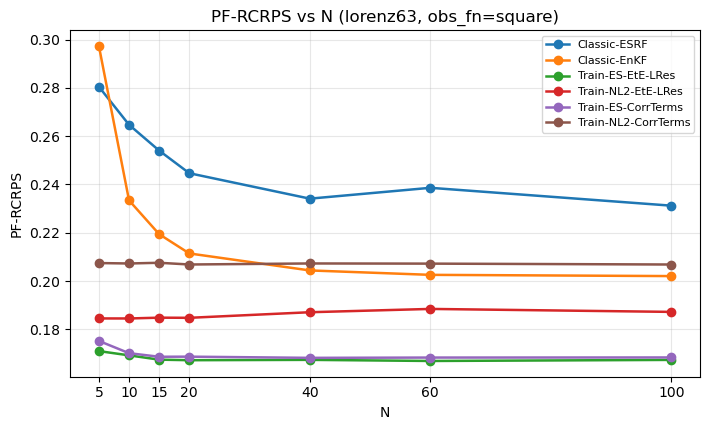

Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_square_notebook/metric_vs_N_PF-RCov-Diff.png


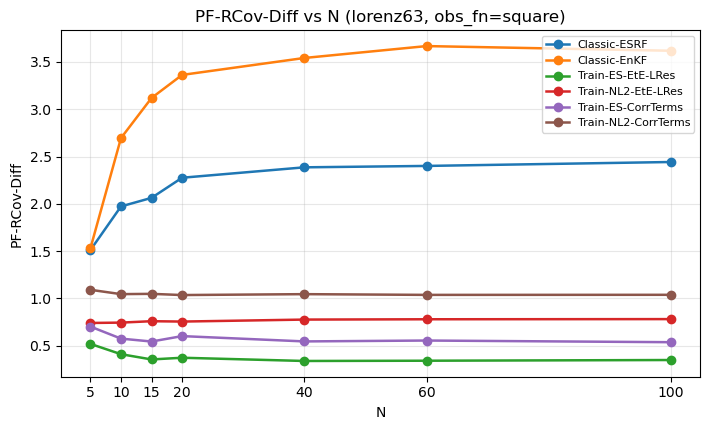

Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_square_notebook/metric_vs_N_PF-RRMSE.png


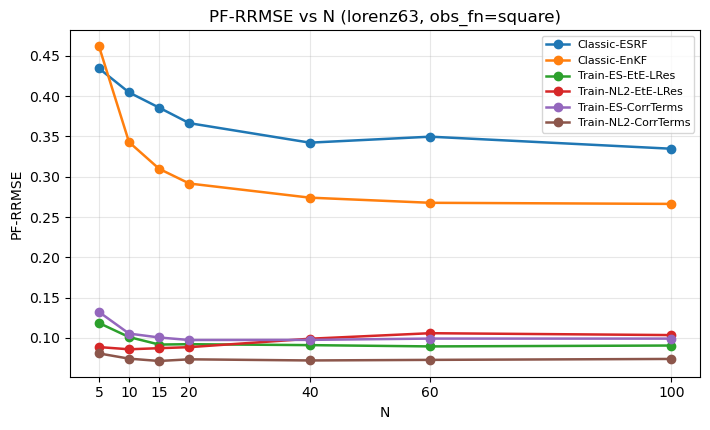

[warn] no valid points for metric=Rank-Hist FreqRange(max-min), method=Classic-ESRF
[warn] no valid points for metric=Rank-Hist FreqRange(max-min), method=Classic-EnKF
Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_square_notebook/metric_vs_N_Rank-Hist_FreqRange_max-min_.png


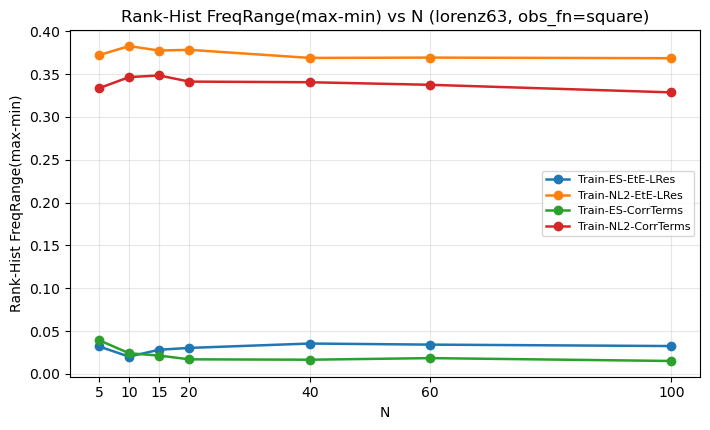

Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_square_notebook/metric_vs_N_RES1.png


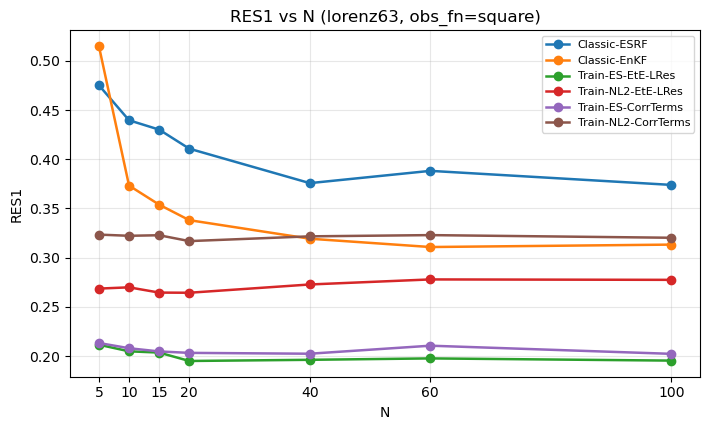

[warn] no valid points for metric=spread-error ratio, method=Classic-ESRF
[warn] no valid points for metric=spread-error ratio, method=Classic-EnKF
Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz63_square_notebook/metric_vs_N_spread-error_ratio.png


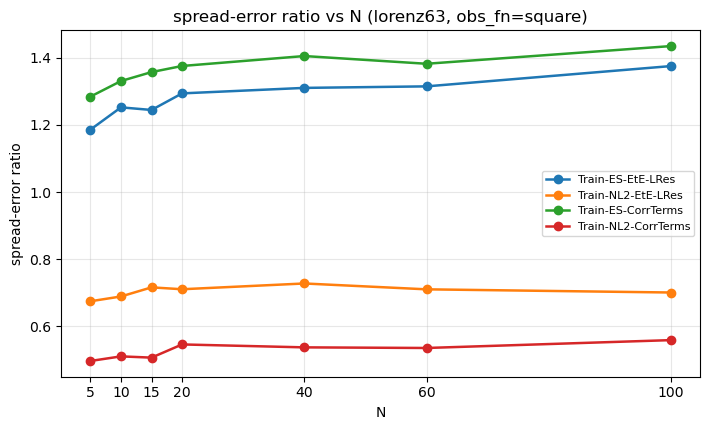

In [90]:
def plot_metric_vs_N(metric_name, metric_keys, save=True):
    fig, ax = plt.subplots(figsize=(7.2, 4.4))

    for spec in all_method_specs:
        x, y = collect_metric_table(spec, VAL_N_LIST, metric_keys)
        valid = np.isfinite(y)
        if np.any(valid):
            ax.plot(x[valid], y[valid], marker='o', linewidth=1.8, label=spec['label'])
        else:
            print(f'[warn] no valid points for metric={metric_name}, method={spec["label"]}')

    ax.set_title(f'{metric_name} vs N ({DATASET}, obs_fn={OBS_FN})')
    ax.set_xlabel('N')
    ax.set_ylabel(metric_name)
    ax.set_xticks(VAL_N_LIST)
    ax.grid(alpha=0.3)
    ax.legend(loc='best', fontsize=8)
    plt.tight_layout()

    if save:
        safe_name = re.sub(r'[^0-9a-zA-Z._-]+', '_', metric_name)
        out = FIG_SAVE_DIR / f'metric_vs_N_{safe_name}.png'
        plt.savefig(out, dpi=180, bbox_inches='tight')
        print('Saved:', out)

    plt.show()


for metric_name, metric_keys in METRIC_SPECS:
    plot_metric_vs_N(metric_name, metric_keys)
